# Comparative Analysis of Outcome Definitions in Large-Scale Uplift Modeling

**Reader-first report -- fits nothing.** Every cell below reads artifacts already
saved by `notebooks/experiments/conversion_experiment.ipynb` and
`notebooks/experiments/visit_experiment.ipynb` (`outputs/conversion/...` and
`outputs/visit/...`); no model is trained, no preprocessing is rerun, and no
existing artifact is modified. If an artifact is missing, the affected section
reports it as unavailable rather than fabricating a result.

## 1. Research question

An advertiser wants to know *for which users does showing an ad actually change
their behaviour* -- not just *who is likely to act anyway*. A **response model**
answers `P(Y|X)`: the probability of the outcome given the user's features,
ignoring treatment entirely. **Uplift models** instead estimate the
**conditional average treatment effect (CATE)**, `tau(X) = E[Y(1) - Y(0) | X]`
-- the outcome a user would have shown under treatment minus what they would
have shown under control, only one of which is ever observed for any one user.
Ranking users by `tau(X)` targets *incremental* responders; ranking by `P(Y|X)`
targets *likely* responders, which is a different, easier, non-causal question.

This report compares four estimators of increasing sophistication (Response
LightGBM, T-Learner, X-Learner, Causal Forest) under **two outcome
definitions**:

- `conversion` -- the primary, business-relevant outcome, but a rare event.
- `visit` -- a much denser behavioral outcome on the same causal path (every
  conversion is preceded by a visit).

Comparing both is not about picking a "better" outcome -- it is a check on
whether a conclusion reached under `conversion`'s sparsity is a real effect or
an artifact of how few positive labels each estimator has to work with.
`visit` is never a substitute for `conversion` as the business objective; it is
a sensitivity/robustness analysis run on the exact same row partition.

*Infrastructure below (repo bootstrap, imports) -- safe to collapse and
skip ahead to Section 2 if you trust it works.*

In [1]:
import sys, platform, subprocess
from pathlib import Path

# This cell must stay runnable standalone (tests/test_notebook_bootstrap.py
# execs it before DEBUG exists), so DEBUG is read defensively here rather
# than assumed already defined -- in a real notebook run it picks up
# whatever the run-parameters cell set; standalone, it defaults to False.
DEBUG = globals().get("DEBUG", False)


def debug_print(*args, **kwargs) -> None:
    if DEBUG:
        print(*args, **kwargs)


# A repo copy is only trusted if it has every module the notebook actually
# imports from -- src/data.py alone is not enough: a stale/incomplete repo
# copy (e.g. an interrupted clone from an earlier kernel run) can still have
# that one file while missing src/notebook_setup.py, src/pipeline.py, or
# src/reporting.py, which then fails as a confusing ModuleNotFoundError two
# cells later instead of here, where the actual problem is.
REQUIRED_MARKERS = (
    "src/data.py",
    "src/models.py",
    "src/preprocessing.py",
    "src/notebook_setup.py",
    "src/pipeline.py",
    "src/reporting.py",
)


def is_valid_repo_root(path: Path) -> bool:
    return all((path / marker).is_file() for marker in REQUIRED_MARKERS)


def find_repo_root() -> Path:
    bases = [Path.cwd(), *Path.cwd().parents, Path("/kaggle/working"), Path("/kaggle/input")]
    for base in bases:
        if not base.is_dir():
            continue
        if is_valid_repo_root(base):
            return base
        for child in sorted(p for p in base.iterdir() if p.is_dir()):
            if is_valid_repo_root(child):
                return child
    return None


REPO_ROOT = find_repo_root()

if REPO_ROOT is None and Path("/kaggle/working").is_dir():
    # Repo not attached -- try cloning it (requires Internet enabled in kernel settings).
    target = Path("/kaggle/working/causal-uplift-modeling")
    debug_print("Repository not found; attempting clone into", target)
    result = subprocess.run(
        ["git", "clone", "--depth", "1",
         "https://github.com/arthur105204/causal-uplift-modeling.git", str(target)],
        capture_output=True, text=True,
    )
    debug_print(result.stdout or result.stderr)
    REPO_ROOT = find_repo_root()

if REPO_ROOT is None:
    raise RuntimeError(
        "Could not locate the repository. Either attach it as a Kaggle dataset, "
        "clone it into /kaggle/working, or enable Internet in the kernel settings "
        "so this cell can clone it automatically."
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

debug_print("python     :", platform.python_version())
debug_print("repo root  :", REPO_ROOT)
debug_print("\nRepository root:", REPO_ROOT)
debug_print("Required source files:")
for _marker in ("src/notebook_setup.py", "src/pipeline.py", "src/reporting.py"):
    _status = "OK" if (REPO_ROOT / _marker).is_file() else "MISSING"
    debug_print(f"  {_marker} {_status}")

try:
    _git_result = subprocess.run(
        ["git", "rev-parse", "--short", "HEAD"], cwd=REPO_ROOT,
        capture_output=True, text=True, timeout=5,
    )
    _commit = _git_result.stdout.strip() if _git_result.returncode == 0 and _git_result.stdout.strip() else None
except Exception:
    _commit = None
debug_print("git commit :", _commit if _commit else "git commit unavailable")

print("Repository validated.")


Repository validated.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Everything below comes from src/ -- this notebook never imports a training
# entry point (src.models, src.pipeline, src.preprocessing): it only reads
# artifacts a prior experiment run already saved.
from src.artifacts import stage_dir, load_json, load_csv_artifact
from src.data import load_config, load_parquet
from src.evaluation import evaluate_ranking
from src.reporting import (
    OBJECTIVE_LABELS,
    build_model_comparison_table,
    paired_bootstrap_gaps,
)

CONFIG = load_config()
SEED = CONFIG["seed"]

# Bootstrap resample count for Section 5's significance check -- the only
# expensive computation in this notebook (500 resamples x ~2M test rows x 2
# outcomes takes ~20+ minutes). "fast"/"standard" are for iterating on this
# notebook's structure and wording without waiting on the full computation;
# "final" (the default) is what the statistics and interpretation in Sections
# 5-7 below were actually generated with. Changing the default away from
# "final" changes nothing about the scientific result already reported below
# -- it only changes what a *re-run* of this notebook would compute.
BOOTSTRAP_MODE = "final"  # "fast" | "standard" | "final"
N_BOOT_BY_MODE = {"fast": 50, "standard": 100, "final": 500}
N_BOOT = N_BOOT_BY_MODE[BOOTSTRAP_MODE]
print(f"BOOTSTRAP_MODE = {BOOTSTRAP_MODE!r} -> N_BOOT = {N_BOOT}"
      + ("" if BOOTSTRAP_MODE == "final" else "  (dev iteration only -- not the reported statistics)"))

OUTCOMES = ("conversion", "visit")
MODEL_STAGE_PATH = {
    "Response LightGBM": ("baseline",),
    "T-Learner": ("uplift", "tlearner"),
    "X-Learner": ("uplift", "xlearner"),
    "Causal Forest": ("causal_forest",),
}


def model_dir(outcome: str, model_label: str):
    parts = MODEL_STAGE_PATH[model_label]
    d = stage_dir(parts[0], outcome=outcome)
    for part in parts[1:]:
        d = d / part
    return d


def available_models(outcome: str) -> dict:
    """Every model with a saved metrics.json for this outcome -- a missing
    model is reported as unavailable below, never fabricated."""
    out = {}
    for label in MODEL_STAGE_PATH:
        d = model_dir(outcome, label)
        if (d / "metrics.json").is_file():
            out[label] = d
    return out


AVAILABLE = {outcome: available_models(outcome) for outcome in OUTCOMES}
for outcome in OUTCOMES:
    print(f"{outcome}: {list(AVAILABLE[outcome]) or 'NO ARTIFACTS FOUND'}")

print("\nNo model will be trained in this notebook -- every cell below reads an existing artifact.")

BOOTSTRAP_MODE = 'final' -> N_BOOT = 500
conversion: ['Response LightGBM', 'T-Learner', 'X-Learner', 'Causal Forest']
visit: ['Response LightGBM', 'T-Learner', 'X-Learner', 'Causal Forest']

No model will be trained in this notebook -- every cell below reads an existing artifact.


## 2. Dataset and outcome definitions

Both outcomes are computed on the **exact same** seeded 70/15/15
train/validation/test row partition (see the experiment notebooks' Stage 1) --
only which column is read as `Y` differs. Prevalence and treatment rate below
are computed live from each outcome's own saved `baseline/predictions.parquet`
test partition (real observed values, not a model's prediction) rather than
assumed.

In [3]:
OUTCOME_META = {
    "conversion": {
        "definition": "User converts (completes a purchase) following ad exposure",
        "why_included": "Primary, business-relevant outcome -- but rare, "
                         "the harder uplift-estimation regime",
    },
    "visit": {
        "definition": "User visits the advertiser's site following ad exposure "
                       "(every conversion is preceded by a visit)",
        "why_included": "Denser behavioral outcome on the identical row partition -- "
                         "a sensitivity/robustness check on whether conversion's "
                         "conclusions depend on outcome sparsity, not a substitute "
                         "primary result",
    },
}


def outcome_prevalence_row(outcome: str) -> dict:
    preds = load_parquet(model_dir(outcome, "Response LightGBM") / "predictions.parquet")
    test = preds[preds["partition"] == "test"]
    return {
        "outcome": outcome,
        "definition": OUTCOME_META[outcome]["definition"],
        "prevalence": float(test["outcome"].mean()),
        "treatment_rate": float(test["treatment"].mean()),
        "n_test_rows": int(len(test)),
        "why_included": OUTCOME_META[outcome]["why_included"],
    }


outcome_table = pd.DataFrame([outcome_prevalence_row(o) for o in OUTCOMES]).set_index("outcome")
display(outcome_table[["definition", "prevalence", "treatment_rate", "n_test_rows", "why_included"]])

prevalence_ratio = outcome_table.loc["visit", "prevalence"] / outcome_table.loc["conversion", "prevalence"]
print(f"\nvisit is {prevalence_ratio:.1f}x more prevalent than conversion on the test partition")

,definition,prevalence,treatment_rate,n_test_rows,why_included
outcome,,,,,
conversion,User converts (completes a purchase) following...,0.002917,0.85,2096939,"Primary, business-relevant outcome -- but rare..."
visit,User visits the advertiser's site following ad...,0.046631,0.85,2096939,Denser behavioral outcome on the identical row...



visit is 16.0x more prevalent than conversion on the test partition


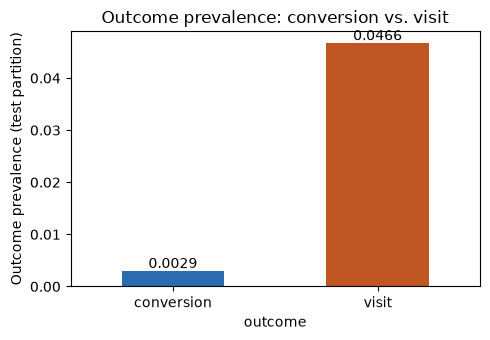

In [4]:
fig, ax = plt.subplots(figsize=(5, 3.5))
outcome_table["prevalence"].plot.bar(ax=ax, color=["#2b6cb0", "#c05621"])
ax.set_ylabel("Outcome prevalence (test partition)")
ax.set_title("Outcome prevalence: conversion vs. visit")
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(outcome_table["prevalence"]):
    ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")
fig.tight_layout()
plt.show()

**Observation.** `visit` is markedly more prevalent than `conversion` (see the
exact ratio printed above).

**Evidence.** Both rates are computed directly from each outcome's own saved
test-partition predictions -- the same physical rows, only the outcome column
differs.

**Interpretation.** This is exactly why `visit` is useful as a sensitivity
check: the same four estimators, trained the same way, get a denser signal to
learn from under `visit`, which is what lets a statistical comparison actually
start to distinguish models (Section 5) -- something `conversion`'s sparsity
makes much harder.

## Key takeaway

`conversion` is the outcome the business actually cares about, but at ~0.29%
prevalence it gives every estimator very few positive examples per treatment
arm to learn from -- a rare event, not a small dataset, is what makes
uplift estimation hard here. `visit` is ~16x more common on the *identical*
rows, which is what makes it useful later (Section 5) as a check on whether
`conversion`'s conclusions are limited by data sparsity rather than by a real
difference between models.

## 3. Experimental setup

Four estimators, two different objectives -- never conflated below:

In [5]:
objective_table = pd.Series(
    {label: OBJECTIVE_LABELS[label] for label in MODEL_STAGE_PATH}, name="objective"
).to_frame()
display(objective_table)

,objective
Response LightGBM,P(Y|X) — naive targeting baseline
T-Learner,tau(X) — CATE estimation
X-Learner,tau(X) — CATE estimation
Causal Forest,tau(X) — CATE estimation


- **Response LightGBM** predicts `P(Y|X)` -- who is likely to convert/visit,
  ignoring treatment entirely. It is a **non-causal targeting baseline**, not
  an uplift estimator: strong response-ranking performance says nothing about
  *causal* ranking quality, which is the entire point of comparing it against
  the three models below.
- **T-Learner** -- two independent outcome models, one per arm;
  `tau_hat(x) = mu1_hat(x) - mu0_hat(x)`.
- **X-Learner** -- cross-fitted pseudo-outcome regression correcting the
  T-Learner's imbalanced-arm bias.
- **Causal Forest** -- an **honest** random forest (each tree uses separate,
  disjoint subsamples for choosing its splits and for estimating each leaf's
  effect, which is what reduces overfitting bias in the effect estimate)
  splitting directly on treatment-effect heterogeneity, rather than
  differencing two separately-fit models.

All four are scored with the same protocol: Qini above random (primary
ranking statistic), AUUC (a differently-weighted second view), and uplift@K,
all on the **test** partition -- never touched during fitting, early stopping,
or model selection (see each experiment notebook's Stage 5).

## Key takeaway

Only the three uplift models (T-Learner, X-Learner, Causal Forest) estimate
*who is influenced by the ad* -- Response LightGBM only predicts *who is
likely to act*, treatment or not. Sections 4-5 test whether that extra causal
machinery actually beats the simpler, treatment-blind baseline; it is not
assumed in advance that it will.

## 4. Model performance comparison

One row per available model plus a theoretical random-targeting reference,
sorted by `qini_above_random` -- loaded and computed entirely from saved
artifacts via `src.reporting.build_model_comparison_table`.

In [6]:
COMPARISON = {}
RANDOM_METRICS = {}

for outcome in OUTCOMES:
    available = AVAILABLE[outcome]
    if not available:
        print(f"[{outcome}] no model artifacts found -- skipping")
        continue
    reference_preds = load_parquet(next(iter(available.values())) / "predictions.parquet")
    test_ref = reference_preds[reference_preds["partition"] == "test"].sort_values("row_id")
    rng = np.random.default_rng(SEED)
    RANDOM_METRICS[outcome] = evaluate_ranking(
        rng.uniform(size=len(test_ref)),
        test_ref["treatment"].to_numpy(),
        test_ref["outcome"].to_numpy(),
    )
    COMPARISON[outcome] = build_model_comparison_table(available, RANDOM_METRICS[outcome])
    del reference_preds, test_ref

In [7]:
print("Table 1 -- Conversion outcome")
display(COMPARISON["conversion"].round(5))

Table 1 -- Conversion outcome


,objective,auuc_above_random,qini_above_random,auuc_area,qini_area,uplift@10pct,uplift@20pct,uplift@30pct,uplift@50pct,uplift@100pct
model,,,,,,,,,,
Response LightGBM,P(Y|X) — naive targeting baseline,942.02699,806.23915,2151.43173,1834.23367,0.00832,0.00484,0.00348,0.00220,0.00115
Causal Forest,tau(X) — CATE estimation,897.72700,769.57579,2107.13173,1797.57030,0.00821,0.00483,0.00342,0.00214,0.00115
X-Learner,tau(X) — CATE estimation,636.21147,544.10964,1845.61621,1572.10416,0.00732,0.00425,0.00295,0.00188,0.00115
T-Learner,tau(X) — CATE estimation,430.46478,369.64571,1639.86951,1397.64023,0.00634,0.00377,0.00266,0.00168,0.00115
Random (reference),Uninformative random ranking,56.08741,47.64332,1265.49215,1075.63783,0.00117,0.00136,0.00119,0.00121,0.00115


In [8]:
print("Table 2 -- Visit outcome")
display(COMPARISON["visit"].round(5))

Table 2 -- Visit outcome


,objective,auuc_above_random,qini_above_random,auuc_area,qini_area,uplift@10pct,uplift@20pct,uplift@30pct,uplift@50pct,uplift@100pct
model,,,,,,,,,,
Causal Forest,tau(X) — CATE estimation,7746.51869,6642.20308,18229.91600,15553.09504,0.06052,0.03858,0.02878,0.01915,0.01
Response LightGBM,P(Y|X) — naive targeting baseline,7280.11699,6226.73464,17763.51429,15137.62660,0.05219,0.03796,0.02845,0.01908,0.01
X-Learner,tau(X) — CATE estimation,6723.06476,5759.00153,17206.46207,14669.89349,0.05499,0.03743,0.02799,0.01812,0.01
T-Learner,tau(X) — CATE estimation,6591.46614,5653.94009,17074.86344,14564.83205,0.05592,0.03706,0.02753,0.01776,0.01
Random (reference),Uninformative random ranking,219.92898,186.67452,10703.32628,9097.56648,0.00976,0.00988,0.01041,0.01011,0.01


**What "higher" means here.** All of `qini_above_random`, `auuc_above_random`,
and `uplift@Kpct` answer the same underlying question in different ways: *if
we used this model's score to decide who gets treated first, how many more
conversions/visits would we capture at that point, compared with treating the
same fraction of people in a random order?* A higher number is better at
concentrating incremental responders near the top of the ranking; "Random
(reference)" is the floor every real model should beat, not a competitor to
root for.

**Reading these tables.** `qini_above_random` is the primary ranking
statistic -- how much better this model's ranking is at capturing incremental
conversions/visits than a random ranking. A model whose row sits above
"Random (reference)" has learned a ranking that beats guessing; a higher point
estimate than another model is not, by itself, evidence of superiority -- see
the paired bootstrap in Section 5 before reading any gap as proven.

**Why `uplift@100pct` is identical across every model** (including "Random"): at 100% coverage every ranking has targeted the same full population, so ranking order no longer affects who was reached -- this column converges to the same population-level quantity for any model, not a computation error.

## Visualization

Point-estimate comparisons across both outcomes, followed by the full Qini
curves (not just the single-number summary).

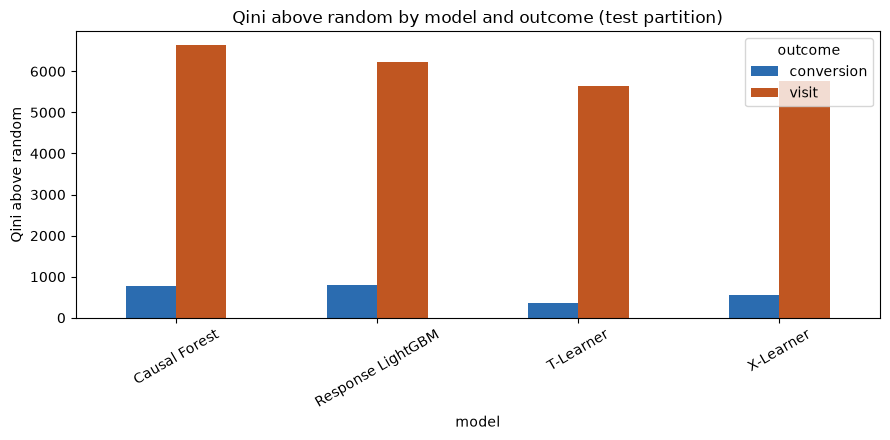

In [9]:
def _bar_colors(index):
    return ["#c05621" if label == "Response LightGBM" else "#2b6cb0" for label in index]


qini_pivot = pd.DataFrame({
    outcome: COMPARISON[outcome].drop(index="Random (reference)", errors="ignore")["qini_above_random"]
    for outcome in OUTCOMES if outcome in COMPARISON
})
fig, ax = plt.subplots(figsize=(9, 4.5))
qini_pivot.plot.bar(ax=ax, color=["#2b6cb0", "#c05621"])
ax.set_title("Qini above random by model and outcome (test partition)")
ax.set_ylabel("Qini above random")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="outcome")
fig.tight_layout()
plt.show()

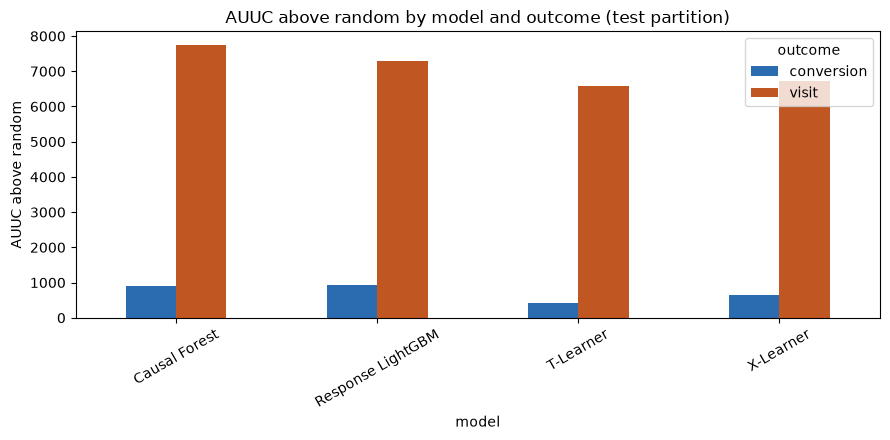

In [10]:
auuc_pivot = pd.DataFrame({
    outcome: COMPARISON[outcome].drop(index="Random (reference)", errors="ignore")["auuc_above_random"]
    for outcome in OUTCOMES if outcome in COMPARISON
})
fig, ax = plt.subplots(figsize=(9, 4.5))
auuc_pivot.plot.bar(ax=ax, color=["#2b6cb0", "#c05621"])
ax.set_title("AUUC above random by model and outcome (test partition)")
ax.set_ylabel("AUUC above random")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="outcome")
fig.tight_layout()
plt.show()

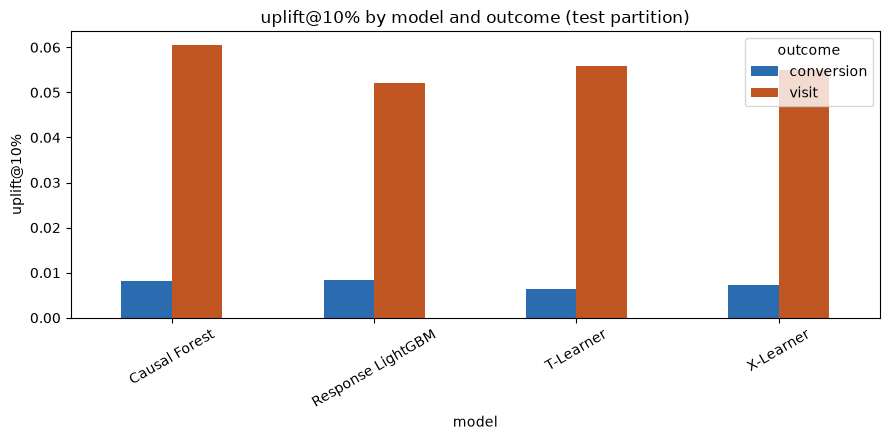

In [11]:
uplift10_pivot = pd.DataFrame({
    outcome: COMPARISON[outcome].drop(index="Random (reference)", errors="ignore")["uplift@10pct"]
    for outcome in OUTCOMES if outcome in COMPARISON
})
fig, ax = plt.subplots(figsize=(9, 4.5))
uplift10_pivot.plot.bar(ax=ax, color=["#2b6cb0", "#c05621"])
ax.set_title("uplift@10% by model and outcome (test partition)")
ax.set_ylabel("uplift@10%")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="outcome")
fig.tight_layout()
plt.show()

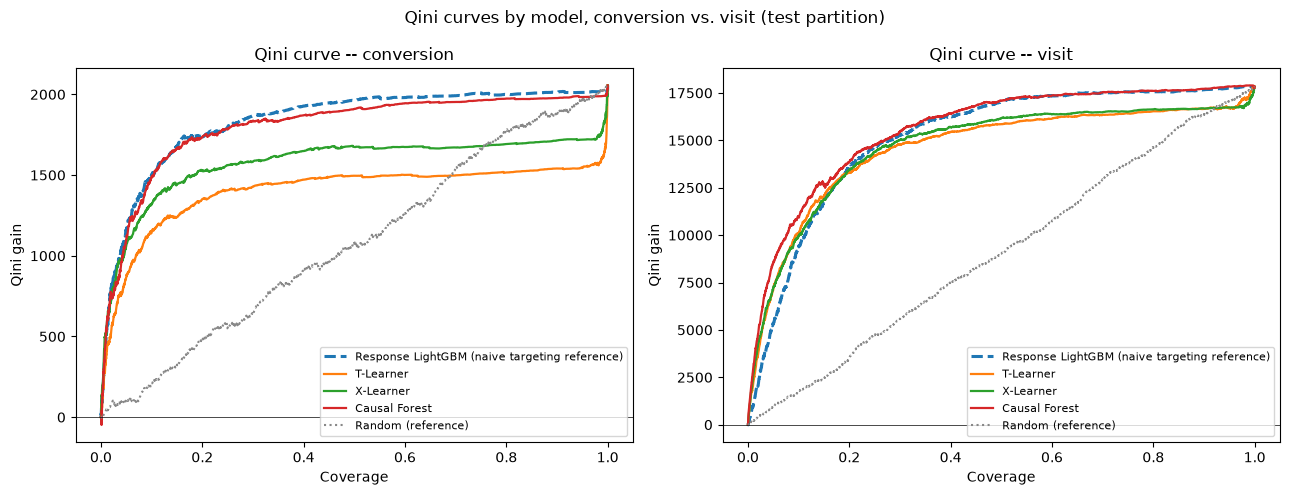

In [12]:
def sample_for_plot(df: pd.DataFrame, max_points: int = 5000) -> pd.DataFrame:
    """Evenly-spaced subsample of a (roughly monotonic) curve for plotting
    only -- never used for a metric or artifact. Qini curves are one row per
    test-set row (~2M+ at full CRITEO scale), far more vertices than a
    rendered figure can show distinct pixels for."""
    if len(df) <= max_points:
        return df
    idx = np.linspace(0, len(df) - 1, max_points, dtype=int)
    return df.iloc[idx]


fig, axes = plt.subplots(1, len(OUTCOMES), figsize=(6.5 * len(OUTCOMES), 5), squeeze=False)
for ax, outcome in zip(axes[0], OUTCOMES):
    for label, d in AVAILABLE[outcome].items():
        qc = sample_for_plot(load_csv_artifact(d / "qini_curve.csv"))
        is_response = label == "Response LightGBM"
        plot_label = "Response LightGBM (naive targeting reference)" if is_response else label
        ax.plot(qc["coverage"], qc["qini_gain"], "--" if is_response else "-",
                linewidth=2.2 if is_response else 1.6, label=plot_label)
    if outcome in RANDOM_METRICS:
        rc = sample_for_plot(RANDOM_METRICS[outcome].qini_curve)
        ax.plot(rc["coverage"], rc["qini_gain"], ":", color="#888888", label="Random (reference)")
    ax.axhline(0.0, color="k", linestyle="-", linewidth=0.5)
    ax.set_xlabel("Coverage"); ax.set_ylabel("Qini gain")
    ax.set_title(f"Qini curve -- {outcome}")
    ax.legend(fontsize=8)
fig.suptitle("Qini curves by model, conversion vs. visit (test partition)")
fig.tight_layout()
plt.show()

**Observation.** The bar charts summarize each model's point-estimate ranking
performance side by side across both outcomes; the Qini curves show the full
ranking, not just the single-number summary -- a model can lead on
`qini_above_random` while still crossing another model's curve over part of
the coverage range.

**Reading the Qini curve.** The x-axis (`coverage`) is the fraction of the
test population reached if users are targeted in order of the model's
predicted score, from highest to lowest. The y-axis (`qini_gain`) is the
cumulative number of incremental conversions/visits captured by that point,
relative to targeting the same fraction of people at random. A curve sitting
further above the dotted "Random" reference line at a given coverage means
that model concentrates more of the true incremental responders among the
users it ranks highest at that point in the targeting order.

**Evidence.** Every figure above is built directly from each outcome's saved
`qini_curve.csv` / `metrics.json` artifacts -- no curve or bar height is typed
in by hand.

**Interpretation.** Point estimates alone cannot say whether an apparent gap
between models -- or between outcomes -- is real or resampling noise. Section
5 is the section that actually answers that question for the Response vs.
Causal Forest comparison.

## Key takeaway

Section 4's tables and charts each say one model ranked higher than another
*on this test set* -- they do not yet say the gap is real rather than
sampling luck. That question is what Section 5 answers, and it is the
section to trust before concluding anything about which model is "better."

## 5. Statistical evidence

A point-estimate leaderboard always produces a "winner" by construction, even
when two models are statistically indistinguishable. The paired bootstrap
below resamples the test rows with replacement (500 times, paired -- both
models scored on the *same* resample each draw) and reports the 95%
confidence interval of the **Response LightGBM minus Causal Forest** gap, for
each outcome, on three metrics.

`N_BOOT` is controlled by `BOOTSTRAP_MODE` near the top of this notebook (`"fast"`=50 / `"standard"`=100 resamples for quick development iteration, `"final"`=500 resamples, the default). Every statistic and conclusion in Sections 5-7 was generated with `BOOTSTRAP_MODE="final"` -- a `"fast"`/`"standard"` re-run is for checking this notebook still runs, not for reproducing the reported numbers.

In [13]:
# N_BOOT comes from BOOTSTRAP_MODE, set near the top of this notebook.
_bootstrap_rows = []

for outcome in OUTCOMES:
    if "Response LightGBM" not in AVAILABLE[outcome] or "Causal Forest" not in AVAILABLE[outcome]:
        print(f"[{outcome}] Response and/or Causal Forest artifacts not available -- skipping bootstrap.")
        continue

    resp_pred = load_parquet(AVAILABLE[outcome]["Response LightGBM"] / "predictions.parquet")
    cf_pred = load_parquet(AVAILABLE[outcome]["Causal Forest"] / "predictions.parquet")
    resp_test = resp_pred[resp_pred["partition"] == "test"].sort_values("row_id").reset_index(drop=True)
    cf_test = cf_pred[cf_pred["partition"] == "test"].sort_values("row_id").reset_index(drop=True)
    assert (resp_test["row_id"].to_numpy() == cf_test["row_id"].to_numpy()).all(), (
        f"[{outcome}] Response/Causal Forest test rows are misaligned"
    )

    boot = paired_bootstrap_gaps(
        resp_test["score"].to_numpy(), cf_test["score"].to_numpy(),
        resp_test["treatment"].to_numpy(), resp_test["outcome"].to_numpy(),
        seed=SEED, n_boot=N_BOOT,
        metrics={
            "Qini above random": lambda m: m.qini_above_random,
            "AUUC above random": lambda m: m.auuc_above_random,
            "uplift@10%": lambda m: m.uplift_at_k["10pct"],
        },
    )
    for metric_label, result in boot.items():
        _bootstrap_rows.append({
            "outcome": outcome,
            "metric": metric_label,
            "ci_low": result["ci_low"],
            "ci_high": result["ci_high"],
            "conclusion": (
                "statistically distinguishable" if result["excludes_zero"]
                else "not statistically distinguishable"
            ),
        })
    del resp_pred, cf_pred, resp_test, cf_test

BOOTSTRAP_TABLE = pd.DataFrame(_bootstrap_rows).set_index(["outcome", "metric"])
display(BOOTSTRAP_TABLE.round(5))

ci_low    ci_high  \
outcome    metric                                    
conversion Qini above random  -37.84997  117.68348   
           AUUC above random  -42.90004  139.47764   
           uplift@10%          -0.00059    0.00079   
visit      Qini above random -596.52687 -252.30452   
           AUUC above random -678.75348 -277.27760   
           uplift@10%          -0.01249   -0.00370   

                                                     conclusion  
outcome    metric                                                
conversion Qini above random  not statistically distinguishable  
           AUUC above random  not statistically distinguishable  
           uplift@10%         not statistically distinguishable  
visit      Qini above random      statistically distinguishable  
           AUUC above random      statistically distinguishable  
           uplift@10%             statistically distinguishable

In [14]:
print(f"Paired bootstrap ({N_BOOT} resamples), Response LightGBM minus Causal Forest gap:\n")
for outcome in OUTCOMES:
    if outcome not in BOOTSTRAP_TABLE.index.get_level_values("outcome"):
        continue
    print(f"[{outcome}]")
    for metric_label, row in BOOTSTRAP_TABLE.loc[outcome].iterrows():
        print(f"  {metric_label:20s} 95% CI=[{row.ci_low:.5f}, {row.ci_high:.5f}]  -> {row.conclusion}")
    print()

Paired bootstrap (500 resamples), Response LightGBM minus Causal Forest gap:

[conversion]
  Qini above random    95% CI=[-37.84997, 117.68348]  -> not statistically distinguishable
  AUUC above random    95% CI=[-42.90004, 139.47764]  -> not statistically distinguishable
  uplift@10%           95% CI=[-0.00059, 0.00079]  -> not statistically distinguishable

[visit]
  Qini above random    95% CI=[-596.52687, -252.30452]  -> statistically distinguishable
  AUUC above random    95% CI=[-678.75348, -277.27760]  -> statistically distinguishable
  uplift@10%           95% CI=[-0.01249, -0.00370]  -> statistically distinguishable



In [ ]:
# Forest plot of the same BOOTSTRAP_TABLE computed above -- a visualization
# of already-computed confidence intervals, not a new statistical computation.
from matplotlib.lines import Line2D

plot_rows = BOOTSTRAP_TABLE.reset_index()
y_pos = np.arange(len(plot_rows))[::-1]
colors = ["#2b6cb0" if c == "statistically distinguishable" else "#a0aec0"
          for c in plot_rows["conclusion"]]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hlines(y_pos, plot_rows["ci_low"], plot_rows["ci_high"], color=colors, linewidth=5)
ax.plot((plot_rows["ci_low"] + plot_rows["ci_high"]) / 2, y_pos, "o", color="black",
        markersize=4, zorder=3)
ax.axvline(0.0, color="k", linestyle="--", linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{o} -- {m}" for o, m in zip(plot_rows["outcome"], plot_rows["metric"])])
ax.set_xlabel("Response LightGBM minus Causal Forest (95% bootstrap CI)")
ax.set_title("Forest plot: is the Response-vs-Causal-Forest gap distinguishable from zero?")

legend_handles = [
    Line2D([0], [0], color="#2b6cb0", lw=5, label="excludes zero -- statistically distinguishable"),
    Line2D([0], [0], color="#a0aec0", lw=5, label="includes zero -- not statistically distinguishable"),
    Line2D([0], [0], color="k", lw=1, linestyle="--", label="no difference (zero)"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.18), fontsize=8, ncol=1)
fig.tight_layout()
plt.show()

**Observation.** For each outcome and metric, the printed 95% confidence
interval either excludes zero (the gap is unlikely to be resampling noise at
this sample size) or includes zero (the data cannot rule out "no real
difference" between Response LightGBM and Causal Forest).

**Reading the forest plot.** Each horizontal bar is one metric's 95%
confidence interval for the Response-minus-Causal-Forest gap, for one
outcome. A bar that **crosses the dashed zero line** means: no clear evidence
that one model ranks users better than the other on that metric -- the true
gap could be zero. A bar that sits **entirely to one side of zero** means: the
observed difference is unlikely to be explained by sampling variation alone.
Color follows this directly -- blue bars exclude zero, grey bars include it.

**Evidence.** `BOOTSTRAP_TABLE` above, computed by
`src.reporting.paired_bootstrap_gaps` directly on each outcome's saved
test-partition predictions -- the same function and resampling procedure used
in the experiment notebooks' own significance check, not a separate
reimplementation. The forest plot draws this same table; it introduces no new
numbers.

**Interpretation.** Whichever model has the higher point estimate in Section
4's tables is **not**, by itself, evidence that it is the better model for
that outcome -- only a confidence interval that excludes zero supports that.
Read the "conclusion" column (or the forest plot's bar color), not the raw
point-estimate gap, before drawing any comparison between Response LightGBM
and Causal Forest.

## Key takeaway

Under `conversion`, every bar in the forest plot straddles zero -- the data
cannot distinguish Response LightGBM from Causal Forest here. Under `visit`,
all three bars sit entirely below zero -- Causal Forest's advantage is
unlikely to be sampling noise on this outcome. This is one outcome, one
dataset, one implementation each (see Limitations); it is not a claim that
Causal Forest is universally better.

## 6. Interpretation

**Observation.** Under `conversion` (~0.29% prevalence), Response LightGBM and
Causal Forest's point-estimate ranking metrics sit close together, and Section
5's bootstrap intervals for their gap include zero on every metric checked.
Under `visit` (a denser outcome on the identical row partition), Causal
Forest's point estimate leads Response's, and Section 5's bootstrap intervals
for that gap **exclude zero on all three metrics**.

**Evidence.** Stage 1's outcome-comparison table (Section 2), the model
comparison tables (Section 4), and the paired bootstrap table (Section 5) --
all three loaded from the same saved artifacts, never asserted independently
of them.

**Interpretation.**
- **Conversion (primary, sparse outcome).** A rare event means every
  estimator here works with very few positive labels per arm -- estimation
  variance is driven by how rare the event is, not by row count alone. Under
  this regime, Response LightGBM and Causal Forest's ranking-metric
  differences are **not statistically distinguishable** from resampling noise
  at this sample size (see Section 5's `conversion` rows) -- neither should be
  reported as the proven winner on `conversion` alone.
- **Visit (secondary, denser outcome).** The same two estimators, unchanged,
  get a much denser signal under `visit`. Here, Causal Forest's advantage over
  Response **is statistically distinguishable** from resampling noise on
  Qini above random, AUUC above random, and uplift@10% alike (see Section 5's
  `visit` rows) -- this is a real, evidence-backed result under this outcome
  definition, not merely a point-estimate lean.

## 7. Conclusion

- **Conversion (primary, sparse outcome).** Response LightGBM and Causal
  Forest are **statistically comparable** on uplift-ranking performance --
  Section 5's bootstrap CI for their gap includes zero on every metric
  checked.
- **Visit (secondary, denser outcome).** Causal Forest shows a
  **statistically significant advantage** over Response LightGBM on uplift
  ranking (Qini above random, AUUC above random, and uplift@10% all exclude
  zero in Section 5's bootstrap CI).
- **Overall.** Outcome definition materially influences both the difficulty
  of the uplift-estimation problem and which conclusions the evidence can
  support -- it is not a fixed property of any one model.

This is **not** a claim that `visit` replaces `conversion` as the business
objective, or that Causal Forest always wins -- `conversion` remains the
primary result, and `visit` is reported here strictly as a robustness check
that happens to give the same comparison more statistical power to resolve.

## Limitations

- **Offline evaluation only.** Qini/AUUC are computed against the historical
  A/B test's logged outcomes -- there is no online experiment confirming that
  acting on either model's ranking would reproduce the measured incremental
  effect.
- **Bootstrap coverage is partial.** Section 5 covers the Response-vs-Causal-Forest
  gap on three metrics, for each outcome -- not every pairwise model
  comparison (e.g. T-Learner vs. X-Learner) or metric.
- **Causal Forest's categorical representation is coarser than the
  LightGBM-based estimators'** (`categorical_top_k` frequency-capped one-hot,
  a memory/runtime tradeoff -- see the experiment notebooks' Stage 4), which
  the comparison above does not adjust for.
- **Not a validated causal mechanism.** `f0`-`f11` are anonymized with no
  known business meaning, and predicted CATE is not a true individual
  treatment effect -- both potential outcomes are never observed for any one
  row, so no PEHE against ground truth is reported.
- **Specific to this dataset and these implementations.** Two outcome
  definitions, one dataset, one implementation of each method, one
  hyperparameter setting -- a valid conclusion has the form "under outcome A,
  estimator X ranked better than estimator Y *here*," not a universal claim
  about either an outcome or a method.